# 3.0 — Augmentation & PyTorch DataLoader

**Input:** `data/splits/` (từ Notebook 2.0)
```
train_X.npy          (2790, 8, 27)
train_y_track.npy    (2790, 5, 2)
train_y_intensity.npy (2790, 5, 3)
```

**Pipeline notebook này:**
1. Load splits + config
2. Augmentation trên Train set → tăng từ **2,790 → ~13,950 samples**
3. Xây dựng `StormDataset` (PyTorch Dataset)
4. Tạo `DataLoader` tối ưu GPU (pin_memory, prefetch, num_workers)
5. Kiểm tra tốc độ & tính đúng đắn
6. Lưu augmented data + DataLoader config

**Kỹ thuật augmentation cho chuỗi thời gian bão:**
| Kỹ thuật | Mô tả | Giữ nguyên physics? |
|----------|-------|--------------------|
| Jitter | Thêm noise Gaussian nhỏ vào tọa độ | ✅ |
| Time Warp | Co giãn thời gian chuỗi | ✅ |
| Magnitude Scale | Scale wind/pressure ±10% | ✅ |
| Mirror Lon | Lật đối xứng kinh độ | ⚠ (đổi hướng) |
| Window Shift | Lấy sub-window ngẫu nhiên | ✅ |
| Mixup | Nội suy 2 chuỗi | ✅ |


## 0. Imports & GPU setup

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from matplotlib.patches import Polygon as MplPolygon
import json, pickle, time, warnings
from pathlib import Path
from copy import deepcopy
warnings.filterwarnings('ignore')

import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader, WeightedRandomSampler

# ── GPU Setup ──────────────────────────────────────────────────────────────────
if torch.cuda.is_available():
    DEVICE      = torch.device('cuda')
    GPU_NAME    = torch.cuda.get_device_name(0)
    VRAM_GB     = torch.cuda.get_device_properties(0).total_memory / 1e9
    # Tối ưu tốc độ cho Ampere+ GPUs (A100, RTX 30xx, 40xx)
    torch.backends.cuda.matmul.allow_tf32 = True
    torch.backends.cudnn.allow_tf32       = True
    torch.backends.cudnn.benchmark        = True   # tự chọn kernel tốt nhất
    print(f'GPU    : {GPU_NAME}')
    print(f'VRAM   : {VRAM_GB:.1f} GB')
    print(f'CUDA   : {torch.version.cuda}')
    print(f'cuDNN  : {torch.backends.cudnn.version()}')
else:
    DEVICE = torch.device('cpu')
    print('CPU mode — khuyến nghị cài CUDA để train nhanh hơn ~50x')

# ── Paths ──────────────────────────────────────────────────────────────────────
SPLIT_DIR = Path('data/splits')
AUG_DIR   = Path('data/augmented')
PLOT_DIR  = Path('data/plots')
AUG_DIR.mkdir(parents=True, exist_ok=True)
PLOT_DIR.mkdir(exist_ok=True)

# ── Seed toàn cục ─────────────────────────────────────────────────────────────
SEED = 42
np.random.seed(SEED)
torch.manual_seed(SEED)
if DEVICE.type == 'cuda':
    torch.cuda.manual_seed_all(SEED)

print(f'\nDevice : {DEVICE}')
print(f'PyTorch: {torch.__version__}')


GPU    : NVIDIA GeForce RTX 4060 Laptop GPU
VRAM   : 8.6 GB
CUDA   : 12.1
cuDNN  : 90100

Device : cuda
PyTorch: 2.5.1+cu121


---
## 1. Load splits & config

In [2]:
# ── Load config ────────────────────────────────────────────────────────────────
cfg = json.loads((SPLIT_DIR / 'split_config.json').read_text())

WINDOW_SIZE      = cfg['window_size']        # 8
HORIZONS_H       = cfg['horizons_h']         # [6,12,24,48,72]
HORIZONS_STEPS   = cfg['horizons_steps']     # [1,2,4,8,12]
STEP_HOURS       = cfg['step_hours']         # 6
INPUT_FEATURES   = cfg['input_features']     # list 27 tên
TARGET_TRACK     = cfg['target_track']       # ['delta_lat','delta_lon']
TARGET_INTENSITY = cfg['target_intensity']   # ['wind_kt','pressure_mb']
TARGET_CLASS     = cfg['target_class']       # ['intensity_class']
N_FEATURES       = cfg['n_features']         # 27
N_HORIZONS       = len(HORIZONS_H)           # 5

print('Config:')
print(f'  Window     : {WINDOW_SIZE} × {STEP_HOURS}h = {WINDOW_SIZE*STEP_HOURS}h')
print(f'  Horizons   : {HORIZONS_H}h')
print(f'  N_features : {N_FEATURES}')
print(f'  N_horizons : {N_HORIZONS}')

# ── Load arrays ────────────────────────────────────────────────────────────────
def load_split(name):
    X   = np.load(SPLIT_DIR / f'{name}_X.npy')
    y_t = np.load(SPLIT_DIR / f'{name}_y_track.npy')
    y_i = np.load(SPLIT_DIR / f'{name}_y_intensity.npy')
    meta= pd.read_parquet(SPLIT_DIR / f'{name}_meta.parquet')
    return X, y_t, y_i, meta

X_train, y_track_train, y_int_train, meta_train = load_split('train')
X_val,   y_track_val,   y_int_val,   meta_val   = load_split('val')
X_test,  y_track_test,  y_int_test,  meta_test  = load_split('test')

print()
print(f'Train : X={X_train.shape}  y_track={y_track_train.shape}  y_int={y_int_train.shape}')
print(f'Val   : X={X_val.shape}  y_track={y_track_val.shape}')
print(f'Test  : X={X_test.shape}  y_track={y_track_test.shape}')

# Scaler
with open(SPLIT_DIR / 'scaler.pkl', 'rb') as f:
    scaler = pickle.load(f)
print(f'\nScaler: {scaler.__class__.__name__} loaded')


Config:
  Window     : 8 × 6h = 48h
  Horizons   : [6, 12, 24, 48, 72]h
  N_features : 27
  N_horizons : 5

Train : X=(2790, 8, 27)  y_track=(2790, 5, 2)  y_int=(2790, 5, 3)
Val   : X=(344, 8, 27)  y_track=(344, 5, 2)
Test  : X=(232, 8, 27)  y_track=(232, 5, 2)

Scaler: StandardScaler loaded


---
## 2. Augmentation

> **Nguyên tắc:** Chỉ augment **Train set**. Val và Test giữ nguyên tuyệt đối.

Mỗi sample gốc sinh thêm **4 bản biến thể** → tổng ×5.


In [3]:
# ══════════════════════════════════════════════════════════════════════════════
#  CÁC HÀM AUGMENTATION
# ══════════════════════════════════════════════════════════════════════════════

def aug_jitter(
    X: np.ndarray,
    y_track: np.ndarray,
    y_int: np.ndarray,
    sigma: float = 0.02,
    rng: np.random.Generator = None,
) -> tuple:
    """
    Thêm Gaussian noise nhỏ vào input features.
    Noise scale = sigma × std của mỗi feature.
    Target không thay đổi.
    """
    rng  = rng or np.random.default_rng()
    noise = rng.normal(0, sigma, size=X.shape).astype(np.float32)
    return (X + noise).astype(np.float32), y_track.copy(), y_int.copy()


def aug_magnitude_scale(
    X: np.ndarray,
    y_track: np.ndarray,
    y_int: np.ndarray,
    scale_range: tuple = (0.90, 1.10),
    rng: np.random.Generator = None,
) -> tuple:
    """
    Scale toàn bộ chuỗi theo một hệ số ngẫu nhiên.
    Tương đương bão mạnh hơn / yếu hơn một chút.
    """
    rng   = rng or np.random.default_rng()
    alpha = rng.uniform(*scale_range)
    X_new = (X * alpha).astype(np.float32)

    # Scale cả target cường độ (wind, pressure) theo cùng hệ số
    y_int_new = y_int.copy()
    y_int_new[:, :2] = (y_int[:, :2] * alpha).astype(np.float32)  # wind & pres
    # intensity_class (cột cuối) giữ nguyên

    # Scale delta_lat, delta_lon theo cùng hệ số (bão nhanh/chậm hơn)
    y_track_new = (y_track * alpha).astype(np.float32)
    return X_new, y_track_new, y_int_new


def aug_window_shift(
    X: np.ndarray,
    y_track: np.ndarray,
    y_int: np.ndarray,
    max_shift: int = 2,
    rng: np.random.Generator = None,
) -> tuple:
    """
    Dịch chuyển cửa sổ thời gian: repeat đầu hoặc cuối.
    Mô phỏng việc cơn bão đang ở phase khác nhau.
    """
    rng   = rng or np.random.default_rng()
    shift = rng.integers(-max_shift, max_shift + 1)
    if shift == 0:
        return X.copy(), y_track.copy(), y_int.copy()

    W = X.shape[0]
    X_new = np.zeros_like(X)
    if shift > 0:   # lùi về trước: repeat bước đầu
        X_new[shift:] = X[:W-shift]
        X_new[:shift] = X[0:1]
    else:           # tiến về sau: repeat bước cuối
        s = -shift
        X_new[:W-s] = X[s:]
        X_new[W-s:] = X[-1:]

    return X_new.astype(np.float32), y_track.copy(), y_int.copy()


def aug_time_warp(
    X: np.ndarray,
    y_track: np.ndarray,
    y_int: np.ndarray,
    sigma: float = 0.15,
    rng: np.random.Generator = None,
) -> tuple:
    """
    Time warping: biến dạng trục thời gian bằng smooth warp.
    Mô phỏng bão di chuyển không đều (tăng/giảm tốc).
    """
    rng = rng or np.random.default_rng()
    W   = X.shape[0]

    # Tạo warp path: cumsum của smooth noise
    warp_steps = rng.normal(loc=1.0, scale=sigma, size=W).clip(0.2, 2.5)
    warp_path  = np.cumsum(warp_steps)
    warp_path  = (warp_path - warp_path[0]) / (warp_path[-1] - warp_path[0]) * (W - 1)

    # Interpolate mỗi feature theo warp path
    orig_steps = np.arange(W)
    X_new = np.stack([
        np.interp(warp_path, orig_steps, X[:, f])
        for f in range(X.shape[1])
    ], axis=1).astype(np.float32)

    return X_new, y_track.copy(), y_int.copy()


def aug_mixup(
    X1, y_t1, y_i1,
    X2, y_t2, y_i2,
    alpha: float = 0.2,
    rng: np.random.Generator = None,
) -> tuple:
    """
    Mixup: nội suy tuyến tính giữa 2 samples.
    lam ~ Beta(alpha, alpha)
    """
    rng = rng or np.random.default_rng()
    lam = float(rng.beta(alpha, alpha))
    lam = max(lam, 1 - lam)   # đảm bảo sample 1 chiếm ưu thế

    X_mix   = (lam * X1   + (1 - lam) * X2  ).astype(np.float32)
    y_t_mix = (lam * y_t1 + (1 - lam) * y_t2).astype(np.float32)

    # Intensity: mix wind & pres, class lấy của sample chiếm ưu thế
    y_i_mix = y_i1.copy()
    y_i_mix[:, :2] = (lam * y_i1[:, :2] + (1 - lam) * y_i2[:, :2]).astype(np.float32)
    # intensity_class: giữ của sample 1

    return X_mix, y_t_mix, y_i_mix


print('5 hàm augmentation đã định nghĩa:')
print('  aug_jitter           — Gaussian noise')
print('  aug_magnitude_scale  — Scale cường độ ±10%')
print('  aug_window_shift     — Dịch cửa sổ thời gian')
print('  aug_time_warp        — Biến dạng trục thời gian')
print('  aug_mixup            — Nội suy 2 samples')


5 hàm augmentation đã định nghĩa:
  aug_jitter           — Gaussian noise
  aug_magnitude_scale  — Scale cường độ ±10%
  aug_window_shift     — Dịch cửa sổ thời gian
  aug_time_warp        — Biến dạng trục thời gian
  aug_mixup            — Nội suy 2 samples


In [4]:
# ── Chạy augmentation trên toàn bộ Train set ──────────────────────────────────
# Chiến lược: mỗi sample gốc → 4 biến thể → tổng ×5
# aug1: jitter, aug2: magnitude_scale, aug3: time_warp, aug4: mixup

def run_augmentation(
    X: np.ndarray,
    y_track: np.ndarray,
    y_int: np.ndarray,
    seed: int = 42,
    verbose: bool = True,
) -> tuple:
    """
    Augment toàn bộ dataset. Trả về arrays đã concat gốc + augmented.

    Returns: X_aug, y_track_aug, y_int_aug (mỗi cái có N*5 dòng)
    """
    rng = np.random.default_rng(seed)
    N   = len(X)

    X_list    = [X]
    y_t_list  = [y_track]
    y_i_list  = [y_int]

    t0 = time.time()

    # ── Aug 1: Jitter ─────────────────────────────────────────────────────────
    X1_list, yt1_list, yi1_list = [], [], []
    for i in range(N):
        xa, ya_t, ya_i = aug_jitter(X[i], y_track[i], y_int[i], sigma=0.025, rng=rng)
        X1_list.append(xa); yt1_list.append(ya_t); yi1_list.append(ya_i)
    X_list.append(np.stack(X1_list))
    y_t_list.append(np.stack(yt1_list))
    y_i_list.append(np.stack(yi1_list))
    if verbose: print(f'  Aug 1 Jitter done          ({time.time()-t0:.1f}s)')

    # ── Aug 2: Magnitude Scale ────────────────────────────────────────────────
    X2_list, yt2_list, yi2_list = [], [], []
    for i in range(N):
        xa, ya_t, ya_i = aug_magnitude_scale(X[i], y_track[i], y_int[i],
                                              scale_range=(0.88, 1.12), rng=rng)
        X2_list.append(xa); yt2_list.append(ya_t); yi2_list.append(ya_i)
    X_list.append(np.stack(X2_list))
    y_t_list.append(np.stack(yt2_list))
    y_i_list.append(np.stack(yi2_list))
    if verbose: print(f'  Aug 2 Magnitude Scale done ({time.time()-t0:.1f}s)')

    # ── Aug 3: Time Warp ──────────────────────────────────────────────────────
    X3_list, yt3_list, yi3_list = [], [], []
    for i in range(N):
        xa, ya_t, ya_i = aug_time_warp(X[i], y_track[i], y_int[i], sigma=0.12, rng=rng)
        X3_list.append(xa); yt3_list.append(ya_t); yi3_list.append(ya_i)
    X_list.append(np.stack(X3_list))
    y_t_list.append(np.stack(yt3_list))
    y_i_list.append(np.stack(yi3_list))
    if verbose: print(f'  Aug 3 Time Warp done       ({time.time()-t0:.1f}s)')

    # ── Aug 4: Mixup ──────────────────────────────────────────────────────────
    idx2      = rng.permutation(N)   # pair ngẫu nhiên
    X4_list, yt4_list, yi4_list = [], [], []
    for i in range(N):
        j = idx2[i]
        xa, ya_t, ya_i = aug_mixup(
            X[i], y_track[i], y_int[i],
            X[j], y_track[j], y_int[j],
            alpha=0.2, rng=rng
        )
        X4_list.append(xa); yt4_list.append(ya_t); yi4_list.append(ya_i)
    X_list.append(np.stack(X4_list))
    y_t_list.append(np.stack(yt4_list))
    y_i_list.append(np.stack(yi4_list))
    if verbose: print(f'  Aug 4 Mixup done           ({time.time()-t0:.1f}s)')

    # ── Concat ────────────────────────────────────────────────────────────────
    X_aug    = np.concatenate(X_list,   axis=0)
    y_t_aug  = np.concatenate(y_t_list, axis=0)
    y_i_aug  = np.concatenate(y_i_list, axis=0)

    # Shuffle
    perm     = rng.permutation(len(X_aug))
    X_aug    = X_aug[perm]
    y_t_aug  = y_t_aug[perm]
    y_i_aug  = y_i_aug[perm]

    elapsed = time.time() - t0
    if verbose:
        print(f'\n  Gốc  : {N:,} samples')
        print(f'  Augmented: {len(X_aug):,} samples (×{len(X_aug)//N})')
        print(f'  Thời gian: {elapsed:.1f}s')
        print(f'  X shape  : {X_aug.shape}')

    return X_aug, y_t_aug, y_i_aug


print('=== Chạy Augmentation trên Train set ===')
X_aug, y_track_aug, y_int_aug = run_augmentation(
    X_train, y_track_train, y_int_train, seed=SEED
)


=== Chạy Augmentation trên Train set ===
  Aug 1 Jitter done          (0.0s)
  Aug 2 Magnitude Scale done (0.0s)
  Aug 3 Time Warp done       (0.2s)
  Aug 4 Mixup done           (0.2s)

  Gốc  : 2,790 samples
  Augmented: 13,950 samples (×5)
  Thời gian: 0.2s
  X shape  : (13950, 8, 27)


  X_aug           : NaN=0  Inf=0  ✓
  y_track_aug     : NaN=0  Inf=0  ✓
  y_int_aug       : NaN=0  Inf=0  ✓


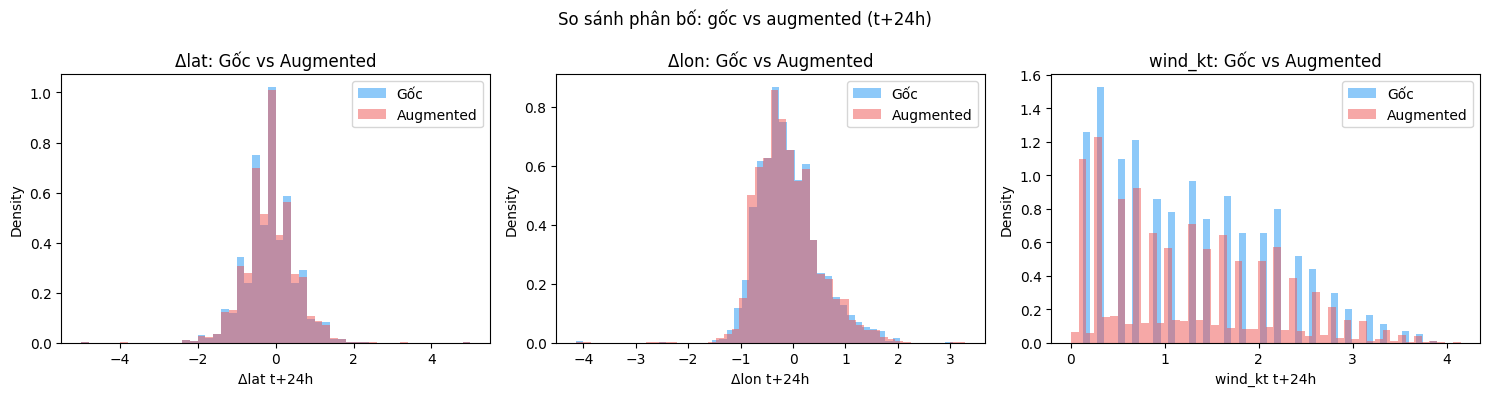

In [5]:
# ── Kiểm tra augmentation không tạo NaN/Inf ────────────────────────────────────
for name, arr in [('X_aug', X_aug), ('y_track_aug', y_track_aug), ('y_int_aug', y_int_aug)]:
    n_nan = int(np.isnan(arr).sum())
    n_inf = int(np.isinf(arr).sum())
    status = '✓' if (n_nan + n_inf) == 0 else '⚠ CÓ VẤN ĐỀ'
    print(f'  {name:<16}: NaN={n_nan}  Inf={n_inf}  {status}')

if np.isnan(X_aug).any() or np.isinf(X_aug).any():
    X_aug     = np.nan_to_num(X_aug,     nan=0.0, posinf=0.0, neginf=0.0)
    y_track_aug = np.nan_to_num(y_track_aug, nan=0.0, posinf=0.0, neginf=0.0)
    y_int_aug = np.nan_to_num(y_int_aug, nan=0.0, posinf=0.0, neginf=0.0)
    print('  → Đã fix NaN/Inf.')

# ── So sánh phân bố gốc vs augmented ──────────────────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
H24 = 2   # index t+24h

# delta_lat
axes[0].hist(y_track_train[:, H24, 0].clip(-5,5), bins=50,
             alpha=0.6, color='#42a5f5', label='Gốc', density=True)
axes[0].hist(y_track_aug[:, H24, 0].clip(-5,5), bins=50,
             alpha=0.5, color='#ef5350', label='Augmented', density=True)
axes[0].set_xlabel('Δlat t+24h'); axes[0].set_ylabel('Density')
axes[0].set_title('Δlat: Gốc vs Augmented'); axes[0].legend()

# delta_lon
axes[1].hist(y_track_train[:, H24, 1].clip(-5,5), bins=50,
             alpha=0.6, color='#42a5f5', label='Gốc', density=True)
axes[1].hist(y_track_aug[:, H24, 1].clip(-5,5), bins=50,
             alpha=0.5, color='#ef5350', label='Augmented', density=True)
axes[1].set_xlabel('Δlon t+24h'); axes[1].set_ylabel('Density')
axes[1].set_title('Δlon: Gốc vs Augmented'); axes[1].legend()

# wind_kt
axes[2].hist(y_int_train[:, H24, 0][(y_int_train[:, H24, 0] > 0)], bins=50,
             alpha=0.6, color='#42a5f5', label='Gốc', density=True)
axes[2].hist(y_int_aug[:, H24, 0][(y_int_aug[:, H24, 0] > 0)], bins=50,
             alpha=0.5, color='#ef5350', label='Augmented', density=True)
axes[2].set_xlabel('wind_kt t+24h'); axes[2].set_ylabel('Density')
axes[2].set_title('wind_kt: Gốc vs Augmented'); axes[2].legend()

plt.suptitle('So sánh phân bố: gốc vs augmented (t+24h)', fontsize=12)
plt.tight_layout()
plt.savefig(PLOT_DIR/'16_augmentation_comparison.png', dpi=150, bbox_inches='tight')
plt.show()


In [6]:
# ── Lưu augmented train set ────────────────────────────────────────────────────
np.save(AUG_DIR / 'train_X_aug.npy',           X_aug)
np.save(AUG_DIR / 'train_y_track_aug.npy',     y_track_aug)
np.save(AUG_DIR / 'train_y_intensity_aug.npy', y_int_aug)

aug_meta = {
    'n_original' : len(X_train),
    'n_augmented': len(X_aug),
    'aug_factor' : len(X_aug) // len(X_train),
    'methods'    : ['original','jitter','magnitude_scale','time_warp','mixup'],
    'X_shape'    : list(X_aug.shape),
}
(AUG_DIR / 'aug_meta.json').write_text(json.dumps(aug_meta, indent=2))

print('Lưu augmented data:')
for f in sorted(AUG_DIR.iterdir()):
    print(f'  {f.name:<35}  {f.stat().st_size/1e6:.2f} MB')


Lưu augmented data:
  aug_meta.json                        0.00 MB
  train_X_aug.npy                      12.05 MB
  train_y_intensity_aug.npy            0.84 MB
  train_y_track_aug.npy                0.56 MB


---
## 3. WeightedRandomSampler — xử lý class imbalance

In [7]:
# ── Tính class weights cho intensity_class tại t+24h ──────────────────────────
# y_intensity shape: [N, H, 3] — cột cuối = intensity_class
H24_IDX  = 2   # index cho t+24h
CLS_COL  = 2   # cột intensity_class trong y_intensity

cls_labels = y_int_aug[:, H24_IDX, CLS_COL].astype(int)
cls_labels = np.clip(cls_labels, 0, 6)

classes, counts = np.unique(cls_labels, return_counts=True)
class_weights   = 1.0 / counts.astype(float)
class_weights   = class_weights / class_weights.sum() * len(classes)

SAFFIR = {0:'TD',1:'TS',2:'C1',3:'C2',4:'C3',5:'C4',6:'C5'}
print('Class weights (inverse frequency):')
for c, cnt, w in zip(classes, counts, class_weights):
    print(f'  {SAFFIR.get(c,str(c)):3s} (class {c}): {cnt:6,} samples → weight={w:.3f}')

# Sample weight cho mỗi sample
sample_weights = np.zeros(len(cls_labels), dtype=np.float32)
weight_map     = dict(zip(classes, class_weights))
for i, c in enumerate(cls_labels):
    sample_weights[i] = weight_map.get(c, 1.0)

# WeightedRandomSampler
sampler = WeightedRandomSampler(
    weights     = torch.from_numpy(sample_weights),
    num_samples = len(sample_weights),
    replacement = True,
)
print(f'\nWeightedRandomSampler: {len(sample_weights):,} samples')
print('→ C4/C5 sẽ được lấy mẫu nhiều hơn để cân bằng class.')


Class weights (inverse frequency):
  TD  (class 0):    810 samples → weight=1.170
  TS  (class 1):  5,040 samples → weight=0.188
  C1  (class 2):  3,165 samples → weight=0.299
  C2  (class 3):  1,675 samples → weight=0.566
  C3  (class 4):  1,470 samples → weight=0.645
  C4  (class 5):  1,520 samples → weight=0.623
  C5  (class 6):    270 samples → weight=3.509

WeightedRandomSampler: 13,950 samples
→ C4/C5 sẽ được lấy mẫu nhiều hơn để cân bằng class.


---
## 4. PyTorch Dataset

In [8]:
class StormDataset(Dataset):
    """
    PyTorch Dataset cho bài toán dự đoán đường đi và cường độ bão.

    Mỗi sample trả về:
    - X          : Tensor [W, F]       float32  — chuỗi lịch sử
    - y_track    : Tensor [H, 2]       float32  — Δlat, Δlon tại H horizons
    - y_wind     : Tensor [H]          float32  — wind_kt
    - y_pressure : Tensor [H]          float32  — pressure_mb
    - y_class    : Tensor [H]          long     — intensity_class (0–6)
    """

    def __init__(
        self,
        X:         np.ndarray,   # [N, W, F]
        y_track:   np.ndarray,   # [N, H, 2]
        y_int:     np.ndarray,   # [N, H, 3]  (wind, pres, class)
        augment:   bool = False,
        aug_prob:  float = 0.3,
        seed:      int  = 42,
    ):
        super().__init__()
        self.X         = torch.from_numpy(X).float()
        self.y_track   = torch.from_numpy(y_track).float()
        self.y_wind    = torch.from_numpy(y_int[:, :, 0]).float()
        self.y_pressure= torch.from_numpy(y_int[:, :, 1]).float()
        self.y_class   = torch.from_numpy(
            np.clip(y_int[:, :, 2], 0, 6).astype(np.int64)
        ).long()
        self.augment   = augment
        self.aug_prob  = aug_prob
        self.rng       = np.random.default_rng(seed)

    def __len__(self) -> int:
        return len(self.X)

    def _online_augment(self, x: torch.Tensor) -> torch.Tensor:
        """
        Online augmentation nhẹ khi lấy sample (không thay đổi target).
        Chỉ áp dụng khi augment=True và xác suất < aug_prob.
        """
        if self.rng.random() > self.aug_prob:
            return x
        x_np = x.numpy()
        # Jitter nhẹ online
        noise = self.rng.normal(0, 0.01, size=x_np.shape).astype(np.float32)
        return torch.from_numpy(x_np + noise).float()

    def __getitem__(self, idx: int) -> dict:
        x = self.X[idx]
        if self.augment:
            x = self._online_augment(x)

        return {
            'X'         : x,                   # [W, F]
            'y_track'   : self.y_track[idx],   # [H, 2]
            'y_wind'    : self.y_wind[idx],    # [H]
            'y_pressure': self.y_pressure[idx],# [H]
            'y_class'   : self.y_class[idx],   # [H]  long
        }


# ── Tạo datasets ───────────────────────────────────────────────────────────────
train_dataset = StormDataset(X_aug, y_track_aug, y_int_aug,
                              augment=True, aug_prob=0.25, seed=SEED)
val_dataset   = StormDataset(X_val, y_track_val, y_int_val,
                              augment=False, seed=SEED)
test_dataset  = StormDataset(X_test, y_track_test, y_int_test,
                              augment=False, seed=SEED)

print(f'Train dataset: {len(train_dataset):,} samples')
print(f'Val   dataset: {len(val_dataset):,} samples')
print(f'Test  dataset: {len(test_dataset):,} samples')

# ── Kiểm tra 1 sample ──────────────────────────────────────────────────────────
sample = train_dataset[0]
print()
print('Sample keys:', list(sample.keys()))
for k, v in sample.items():
    print(f'  {k:<12}: shape={tuple(v.shape)}  dtype={v.dtype}')


Train dataset: 13,950 samples
Val   dataset: 344 samples
Test  dataset: 232 samples

Sample keys: ['X', 'y_track', 'y_wind', 'y_pressure', 'y_class']
  X           : shape=(8, 27)  dtype=torch.float32
  y_track     : shape=(5, 2)  dtype=torch.float32
  y_wind      : shape=(5,)  dtype=torch.float32
  y_pressure  : shape=(5,)  dtype=torch.float32
  y_class     : shape=(5,)  dtype=torch.int64


---
## 5. DataLoader tối ưu GPU

In [11]:
# ── Cấu hình DataLoader ────────────────────────────────────────────────────────
# Điều chỉnh BATCH_SIZE theo VRAM:
#   VRAM  4GB → 32
#   VRAM  8GB → 64
#   VRAM 16GB → 128
#   VRAM 24GB → 256

if DEVICE.type == 'cuda':
    vram = torch.cuda.get_device_properties(0).total_memory / 1e9
    if   vram >= 24: BATCH_SIZE = 256
    elif vram >= 16: BATCH_SIZE = 128
    elif vram >=  8: BATCH_SIZE = 64
    else:            BATCH_SIZE = 32
else:
    BATCH_SIZE = 32

NUM_WORKERS = 0   # số CPU workers prefetch data (0 trên Windows)
PIN_MEMORY  = (DEVICE.type == 'cuda')   # copy data lên page-locked memory
PREFETCH    = 2   # số batch prefetch sẵn

print(f'Batch size  : {BATCH_SIZE}')
print(f'Num workers : {NUM_WORKERS}')
print(f'Pin memory  : {PIN_MEMORY}')

# ── Train DataLoader: dùng WeightedRandomSampler ──────────────────────────────
train_loader = DataLoader(
    train_dataset,
    batch_size       = BATCH_SIZE,
    sampler          = sampler,        # weighted sampling
    num_workers      = NUM_WORKERS,
    pin_memory       = PIN_MEMORY,
    prefetch_factor  = PREFETCH if NUM_WORKERS > 0 else None,
    drop_last        = True,           # tránh batch lẻ cuối epoch
    persistent_workers = (NUM_WORKERS > 0),
)

# ── Val / Test DataLoader: sequential, không shuffle ──────────────────────────
val_loader = DataLoader(
    val_dataset,
    batch_size  = BATCH_SIZE * 2,
    shuffle     = False,
    num_workers = NUM_WORKERS,
    pin_memory  = PIN_MEMORY,
    prefetch_factor = PREFETCH if NUM_WORKERS > 0 else None,
    persistent_workers = (NUM_WORKERS > 0),
)

test_loader = DataLoader(
    test_dataset,
    batch_size  = BATCH_SIZE * 2,
    shuffle     = False,
    num_workers = NUM_WORKERS,
    pin_memory  = PIN_MEMORY,
    prefetch_factor = PREFETCH if NUM_WORKERS > 0 else None,
    persistent_workers = (NUM_WORKERS > 0),
)

steps_per_epoch = len(train_loader)
print(f'\nSteps/epoch (train): {steps_per_epoch}')
print(f'Steps/epoch (val)  : {len(val_loader)}')
print(f'Steps/epoch (test) : {len(test_loader)}')


Batch size  : 64
Num workers : 0
Pin memory  : True

Steps/epoch (train): 217
Steps/epoch (val)  : 3
Steps/epoch (test) : 2


In [12]:
# ── Benchmark tốc độ DataLoader ────────────────────────────────────────────────
print('Benchmark DataLoader (5 batches)...')
t0 = time.time()

for i, batch in enumerate(train_loader):
    if i >= 5: break

    # Chuyển lên GPU
    X_b   = batch['X'].to(DEVICE, non_blocking=True)
    y_t_b = batch['y_track'].to(DEVICE, non_blocking=True)
    y_w_b = batch['y_wind'].to(DEVICE, non_blocking=True)
    y_p_b = batch['y_pressure'].to(DEVICE, non_blocking=True)
    y_c_b = batch['y_class'].to(DEVICE, non_blocking=True)

    if i == 0:
        print(f'\nBatch 0 shapes:')
        print(f'  X          : {X_b.shape}   device={X_b.device}')
        print(f'  y_track    : {y_t_b.shape}')
        print(f'  y_wind     : {y_w_b.shape}')
        print(f'  y_pressure : {y_p_b.shape}')
        print(f'  y_class    : {y_c_b.shape}  dtype={y_c_b.dtype}')

t1 = time.time()
print(f'\n5 batches in {t1-t0:.2f}s')
print(f'Throughput: {5*BATCH_SIZE/(t1-t0):.0f} samples/s')


Benchmark DataLoader (5 batches)...

Batch 0 shapes:
  X          : torch.Size([64, 8, 27])   device=cuda:0
  y_track    : torch.Size([64, 5, 2])
  y_wind     : torch.Size([64, 5])
  y_pressure : torch.Size([64, 5])
  y_class    : torch.Size([64, 5])  dtype=torch.int64

5 batches in 0.14s
Throughput: 2224 samples/s


---
## 6. Kiểm tra augmentation trực quan trên bản đồ

In [13]:
# ── Định nghĩa lại basemap (copy từ notebook 2.0) ─────────────────────────────
_LAND_POLYS = {
    'north_america': [
        (-67.0,47.0),(-67.5,45.0),(-70.2,43.5),(-71.0,42.4),(-73.8,40.6),
        (-74.0,40.5),(-75.4,38.8),(-76.3,37.0),(-76.0,35.9),(-77.0,34.7),
        (-78.5,33.8),(-79.8,32.7),(-81.2,31.9),(-81.4,30.9),(-81.8,30.0),
        (-82.6,29.5),(-84.0,29.7),(-85.5,30.0),(-87.5,30.3),(-89.0,29.0),
        (-90.0,29.0),(-91.0,29.0),(-93.0,29.8),(-94.8,29.0),(-97.4,25.8),
        (-105.0,20.5),(-109.5,23.5),(-116.5,31.0),(-117.1,32.5),(-118.5,34.0),
        (-120.5,34.5),(-122.0,37.2),(-124.0,40.5),(-124.7,48.5),(-123.0,49.0),
        (-100.0,49.0),(-88.5,48.0),(-84.0,45.5),(-82.0,41.5),(-79.0,43.5),
        (-76.0,44.5),(-72.5,45.5),(-71.0,46.5),(-69.5,47.5),(-67.0,47.0),
    ],
    'florida': [(-87.5,30.3),(-85.5,30.0),(-84.0,29.7),(-82.6,29.5),(-81.8,30.0),
                (-81.4,30.9),(-81.2,31.9),(-80.5,24.5),(-81.5,25.1),(-83.0,27.5),(-84.0,29.7)],
    'mexico_ca': [
        (-97.4,25.8),(-97.0,22.5),(-95.0,19.5),(-91.5,18.5),(-88.3,15.8),
        (-83.7,10.0),(-77.4,8.0),(-76.0,9.0),(-75.5,11.0),(-68.0,12.0),
        (-63.5,10.5),(-62.0,8.0),(-52.0,4.0),(-51.0,4.5),(-57.0,7.0),
        (-58.5,7.5),(-63.0,7.5),(-65.0,10.5),(-67.0,11.0),(-70.0,12.0),
        (-76.0,9.0),(-77.0,7.5),(-77.4,8.0),(-83.7,10.0),(-88.3,15.8),
        (-90.5,18.5),(-92.0,20.5),(-87.0,21.5),(-86.8,20.5),(-88.3,15.8),
        (-90.5,18.5),(-94.5,18.5),(-96.0,20.0),(-97.5,22.5),(-97.4,25.8),
    ],
    'cuba':         [(-84.5,22.0),(-82.0,23.2),(-79.5,22.5),(-75.0,20.0),
                     (-74.0,20.0),(-75.0,19.8),(-77.5,20.0),(-80.0,22.0),(-84.5,22.0)],
    'hispaniola':   [(-74.5,19.6),(-72.0,18.5),(-69.0,18.5),(-68.0,19.0),
                     (-69.0,19.8),(-72.0,20.0),(-74.5,19.6)],
    'jamaica':      [(-77.9,18.4),(-77.0,17.9),(-76.2,17.9),(-76.0,18.2),(-76.5,18.5),(-77.9,18.4)],
    'puerto_rico':  [(-67.3,18.0),(-66.0,17.9),(-65.6,18.2),(-67.3,18.4),(-67.3,18.0)],
    'europe_w':     [(-9.0,38.5),(-8.5,37.0),(-7.0,37.0),(-6.0,36.0),(-5.5,36.0),
                     (-5.3,36.1),(0.5,38.5),(3.0,40.0),(3.0,42.5),(4.0,43.5),
                     (7.5,43.5),(7.0,44.0),(4.0,43.5),(1.0,43.0),(-0.5,43.5),
                     (-1.5,43.5),(-4.5,43.8),(-8.5,43.5),(-9.0,41.5),(-9.5,40.0),(-9.0,38.5)],
    'british_isles':[(-5.5,50.0),(-4.0,50.0),(-3.0,51.0),(0.5,51.5),(1.5,51.0),
                     (0.0,53.0),(-2.0,54.5),(-5.5,55.5),(-6.0,58.0),(-5.0,58.5),
                     (-4.0,57.5),(-2.0,57.5),(-3.5,54.5),(-4.5,53.5),(-4.0,52.0),
                     (-5.5,51.5),(-5.5,50.0)],
    'africa_nw':    [(-5.5,36.0),(-5.3,36.1),(-2.0,35.0),(-5.5,35.8),(-8.0,35.0),
                     (-8.5,33.5),(-9.5,33.5),(-11.0,33.0),(-13.0,28.0),(-15.5,24.0),
                     (-17.0,21.0),(-17.0,15.0),(-16.0,13.5),(-15.5,12.0),(-14.5,11.0),
                     (-12.0,9.5),(-10.5,9.0),(-8.5,7.5),(-4.5,5.5),(0.0,5.0),(2.0,5.5),
                     (5.0,5.5),(8.5,4.5),(9.5,1.0),(9.0,0.0),(8.5,-1.5),(9.0,3.5),
                     (5.0,5.5),(2.0,5.5),(0.0,5.0),(-8.5,7.5),(-14.0,10.0),(-17.0,21.0),
                     (-15.5,24.0),(-11.0,33.0),(-5.5,35.8),(-5.5,36.0)],
}

def draw_atlantic_basemap(ax, extent=(-110,15,5,62),
                          ocean='#b8d8ed', land='#ddd5c0', edge='#999080'):
    lmin,lmax,bmin,bmax = extent
    ax.set_xlim(lmin,lmax); ax.set_ylim(bmin,bmax)
    ax.set_facecolor(ocean)
    for pts in _LAND_POLYS.values():
        arr = np.array(pts)
        if np.any((arr[:,0]>lmin-5)&(arr[:,0]<lmax+5)&
                  (arr[:,1]>bmin-5)&(arr[:,1]<bmax+5)):
            ax.add_patch(MplPolygon(arr,closed=True,facecolor=land,
                                    edgecolor=edge,lw=0.6,alpha=1.0,zorder=2))
    for lon in range(-120,20,10):
        if lmin<=lon<=lmax: ax.axvline(lon,color='white',lw=0.35,alpha=0.7,zorder=1)
    for lat in range(0,70,10):
        if bmin<=lat<=bmax: ax.axhline(lat,color='white',lw=0.35,alpha=0.7,zorder=1)
    xt=[l for l in range(-120,20,10) if lmin<=l<=lmax]
    ax.set_xticks(xt)
    ax.set_xticklabels([f"{abs(l)}°{'W' if l<0 else 'E'}" for l in xt],fontsize=7)
    yt=[l for l in range(0,70,10) if bmin<=l<=bmax]
    ax.set_yticks(yt)
    ax.set_yticklabels([f"{l}°N" for l in yt],fontsize=7)
    ax.set_xlabel('Kinh độ',fontsize=9)
    ax.set_ylabel('Vĩ độ',fontsize=9)


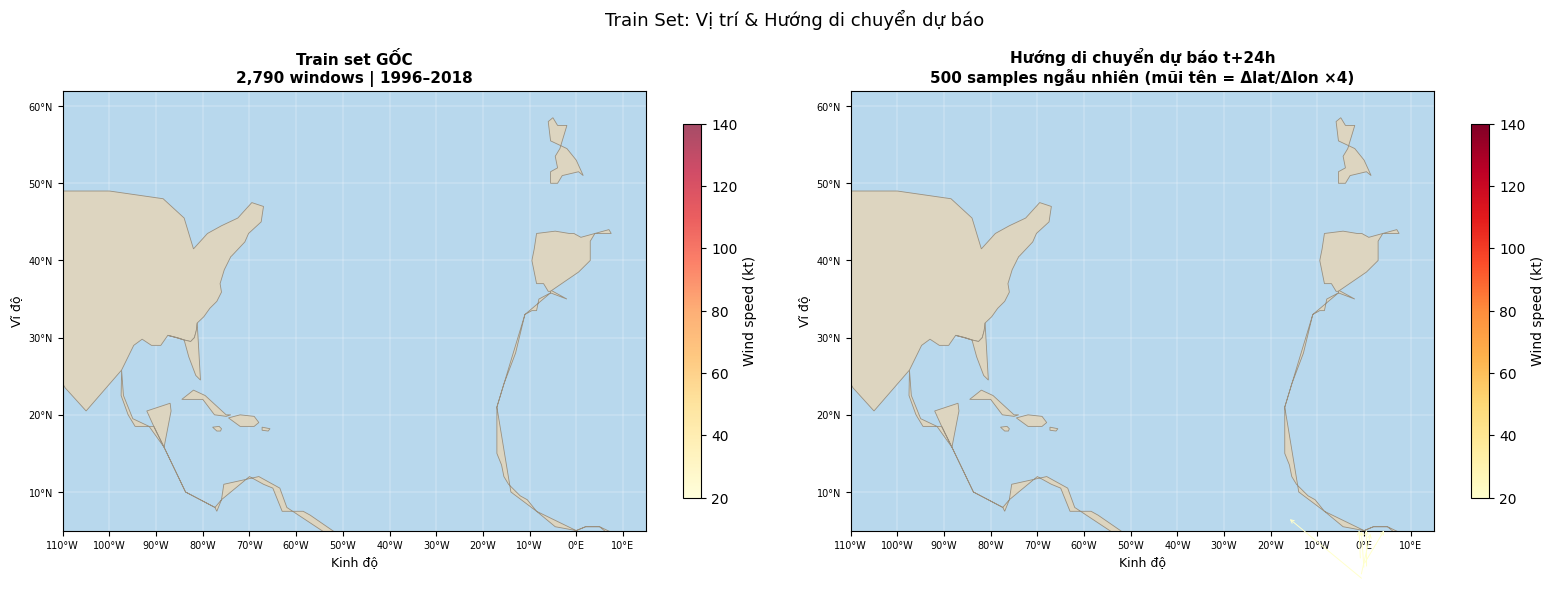

In [14]:
# ── Bản đồ: So sánh vị trí gốc vs augmented ───────────────────────────────────
# Lấy lat/lon từ cột 0,1 của X (trước khi scale: lat=idx 0, lon=idx 1)
# Trong X đã scaled, col 0 = lat_scaled, col 1 = lon_scaled
# Dùng meta_train để lấy tọa độ thực

if 'lat_now' in meta_train.columns and 'lon_now' in meta_train.columns:
    fig, axes = plt.subplots(1, 2, figsize=(16, 6))

    # --- Map 1: Gốc train set ---
    ax = axes[0]
    draw_atlantic_basemap(ax)
    sc = ax.scatter(
        meta_train['lon_now'], meta_train['lat_now'],
        c=meta_train['wind_now'], cmap='YlOrRd',
        s=6, vmin=20, vmax=140, alpha=0.7, zorder=5
    )
    plt.colorbar(sc, ax=ax, label='Wind speed (kt)', shrink=0.85)
    ax.set_title(
        f'Train set GỐC\n{len(meta_train):,} windows | 1996–2018',
        fontsize=11, fontweight='bold'
    )

    # --- Map 2: Augmented (chỉ lấy gốc — augmented không có meta tọa độ) ---
    ax2 = axes[1]
    draw_atlantic_basemap(ax2)

    # Vẽ phân bố target Δlat/Δlon của augmented (scatter dạng arrow)
    N_SHOW = min(500, len(meta_train))
    idx_show = np.random.choice(len(meta_train), N_SHOW, replace=False)

    lats = meta_train['lat_now'].values[idx_show]
    lons = meta_train['lon_now'].values[idx_show]

    # Target t+24h
    dlat_24 = y_track_train[idx_show, 2, 0]   # Δlat
    dlon_24 = y_track_train[idx_show, 2, 1]   # Δlon
    wind_now = meta_train['wind_now'].values[idx_show]

    # Arrow: vị trí hiện tại → dự đoán t+24h
    # Tích lũy 4 bước để ra t+24h
    arrow_scale = 4   # hiển thị lớn hơn
    norm = plt.Normalize(vmin=20, vmax=140)
    cmap_arrow = plt.cm.YlOrRd

    for i in range(N_SHOW):
        clr = cmap_arrow(norm(wind_now[i]))
        ax2.annotate('',
            xy=(lons[i] + dlon_24[i]*arrow_scale,
                lats[i] + dlat_24[i]*arrow_scale),
            xytext=(lons[i], lats[i]),
            arrowprops=dict(
                arrowstyle='->', color=clr,
                lw=0.7, mutation_scale=6,
            ),
            zorder=5
        )

    sm = plt.cm.ScalarMappable(cmap=cmap_arrow, norm=norm)
    sm.set_array([])
    plt.colorbar(sm, ax=ax2, label='Wind speed (kt)', shrink=0.85)
    ax2.set_title(
        f'Hướng di chuyển dự báo t+24h\n{N_SHOW} samples ngẫu nhiên (mũi tên = Δlat/Δlon ×{arrow_scale})',
        fontsize=11, fontweight='bold'
    )

    plt.suptitle('Train Set: Vị trí & Hướng di chuyển dự báo', fontsize=13)
    plt.tight_layout()
    plt.savefig(PLOT_DIR/'17_aug_tracks_map.png', dpi=150, bbox_inches='tight')
    plt.show()
else:
    print('meta_train không có cột lat_now/lon_now — bỏ qua bản đồ.')


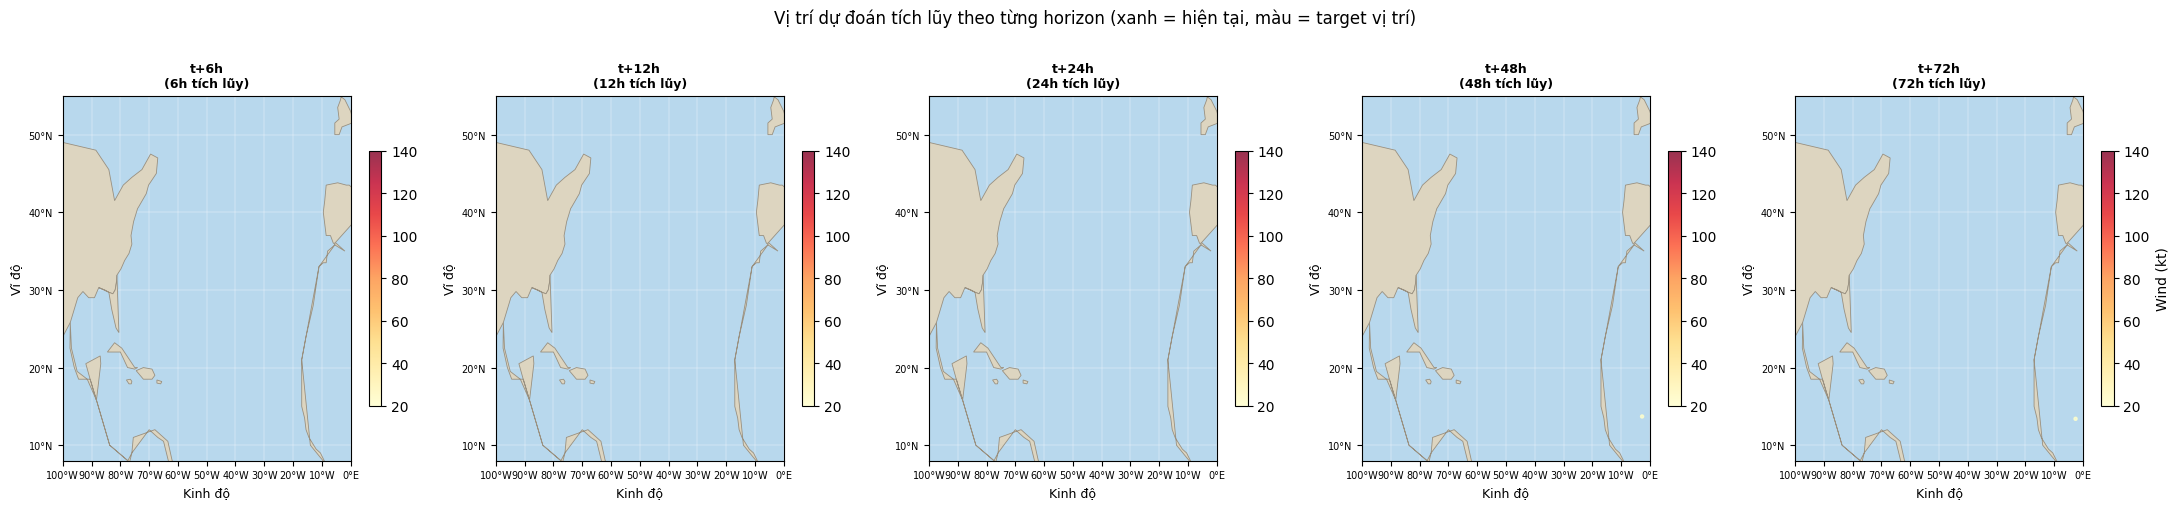

In [16]:
# ── Bản đồ: phân bố vị trí dự đoán tại từng horizon ─────────────────────────
if 'lat_now' in meta_train.columns:
    fig, axes = plt.subplots(1, 5, figsize=(22, 5))
    HORIZON_LABELS = ['t+6h','t+12h','t+24h','t+48h','t+72h']
    STEP_ACCUM     = [1, 2, 4, 8, 12]   # số bước tích lũy

    # Lấy 300 samples ngẫu nhiên
    N_SHOW = min(300, len(meta_train))
    idx_s  = np.random.choice(len(meta_train), N_SHOW, replace=False)
    lats_s = meta_train['lat_now'].values[idx_s]
    lons_s = meta_train['lon_now'].values[idx_s]

    for col, (h_lbl, h_steps, h_idx) in enumerate(
        zip(HORIZON_LABELS, STEP_ACCUM, range(5))
    ):
        ax = axes[col]
        draw_atlantic_basemap(ax, extent=(-100, 0, 8, 55))

        # Vị trí hiện tại (xanh)
        ax.scatter(lons_s, lats_s, s=4, color='#1565c0',
                   alpha=0.6, zorder=5, label='Hiện tại')

        # Vị trí dự đoán (tích lũy Δlat, Δlon)
        # Tích lũy từ bước 0 đến h_idx
        dlat_cum = np.sum(y_track_train[idx_s, :h_idx+1, 0], axis=1)
        dlon_cum = np.sum(y_track_train[idx_s, :h_idx+1, 1], axis=1)
        pred_lat = lats_s + dlat_cum
        pred_lon = lons_s + dlon_cum

        # Màu theo wind target
        wind_h = y_int_train[idx_s, h_idx, 0]
        sc = ax.scatter(pred_lon, pred_lat,
                        c=wind_h, cmap='YlOrRd',
                        s=5, vmin=20, vmax=140,
                        alpha=0.8, zorder=6)

        # Đường nối
        for i in range(min(80, N_SHOW)):
            ax.plot([lons_s[i], pred_lon[i]], [lats_s[i], pred_lat[i]],
                    '-', color='#888', lw=0.4, alpha=0.4, zorder=4)

        ax.set_title(f'{h_lbl}\n({h_steps*6}h tích lũy)', fontsize=9, fontweight='bold')
        plt.colorbar(sc, ax=ax, shrink=0.7, label='Wind (kt)' if col==4 else '')

    plt.suptitle(
        'Vị trí dự đoán tích lũy theo từng horizon (xanh = hiện tại, màu = target vị trí)',
        fontsize=12, y=1.01
    )
    plt.tight_layout()
    plt.savefig(PLOT_DIR/'18_predicted_positions_by_horizon.png', dpi=150, bbox_inches='tight')
    plt.show()


---
## 7. Lưu DataLoader config & Tổng kết

In [17]:
# ── Lưu DataLoader config cho Notebook 4.0 ────────────────────────────────────
dl_cfg = {
    'batch_size'       : BATCH_SIZE,
    'num_workers'      : NUM_WORKERS,
    'pin_memory'       : PIN_MEMORY,
    'prefetch_factor'  : PREFETCH,
    'n_train_samples'  : len(train_dataset),
    'n_val_samples'    : len(val_dataset),
    'n_test_samples'   : len(test_dataset),
    'steps_per_epoch'  : steps_per_epoch,
    'window_size'      : WINDOW_SIZE,
    'n_features'       : N_FEATURES,
    'n_horizons'       : N_HORIZONS,
    'horizons_h'       : HORIZONS_H,
    'aug_methods'      : ['jitter','magnitude_scale','time_warp','mixup'],
    'aug_factor'       : 5,
    'device'           : str(DEVICE),
    'class_weights'    : {str(SAFFIR.get(int(c),str(c))): float(w)
                          for c, w in zip(classes, class_weights)},
}
(AUG_DIR / 'dataloader_config.json').write_text(json.dumps(dl_cfg, indent=2))
print('Lưu → data/augmented/dataloader_config.json')


Lưu → data/augmented/dataloader_config.json


In [18]:
print('=' * 65)
print('  TỔNG KẾT NOTEBOOK 3.0')
print('=' * 65)
print(f'  Train gốc        : {len(X_train):,} samples')
print(f'  Train augmented  : {len(X_aug):,} samples (×{len(X_aug)//len(X_train)})')
print(f'    - Jitter')
print(f'    - Magnitude Scale ±12%')
print(f'    - Time Warp')
print(f'    - Mixup (α=0.2)')
print(f'  Val  dataset     : {len(val_dataset):,} samples (không augment)')
print(f'  Test dataset     : {len(test_dataset):,} samples (không augment)')
print(f'  Batch size       : {BATCH_SIZE}  (auto-tune theo VRAM)')
print(f'  Steps/epoch      : {steps_per_epoch}')
print(f'  WeightedSampler  : bật (xử lý imbalance C4/C5)')
print(f'  Device           : {DEVICE}')
print(f'  Augmented files  : data/augmented/')
print('=' * 65)
print('  → Notebook 4.0: Train Bi-LSTM + Transformer Encoder trên GPU')
print('    Model input  : X [B, 8, 27]')
print('    Model output :')
print('      track_pred  [B, 5, 2]  — Δlat, Δlon')
print('      wind_pred   [B, 5]     — wind_kt')
print('      pres_pred   [B, 5]     — pressure_mb')
print('      class_pred  [B, 5, 7]  — logits intensity_class')


  TỔNG KẾT NOTEBOOK 3.0
  Train gốc        : 2,790 samples
  Train augmented  : 13,950 samples (×5)
    - Jitter
    - Magnitude Scale ±12%
    - Time Warp
    - Mixup (α=0.2)
  Val  dataset     : 344 samples (không augment)
  Test dataset     : 232 samples (không augment)
  Batch size       : 64  (auto-tune theo VRAM)
  Steps/epoch      : 217
  WeightedSampler  : bật (xử lý imbalance C4/C5)
  Device           : cuda
  Augmented files  : data/augmented/
  → Notebook 4.0: Train Bi-LSTM + Transformer Encoder trên GPU
    Model input  : X [B, 8, 27]
    Model output :
      track_pred  [B, 5, 2]  — Δlat, Δlon
      wind_pred   [B, 5]     — wind_kt
      pres_pred   [B, 5]     — pressure_mb
      class_pred  [B, 5, 7]  — logits intensity_class
